In [1]:
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt

# Настройка чтобы графики отображались прямо в ноутбуке
%matplotlib inline

client = clickhouse_connect.get_client(
    host="localhost",
    port=8123,
    username="default",
    password="admin"
)
print("Подключились!")

Подключились!


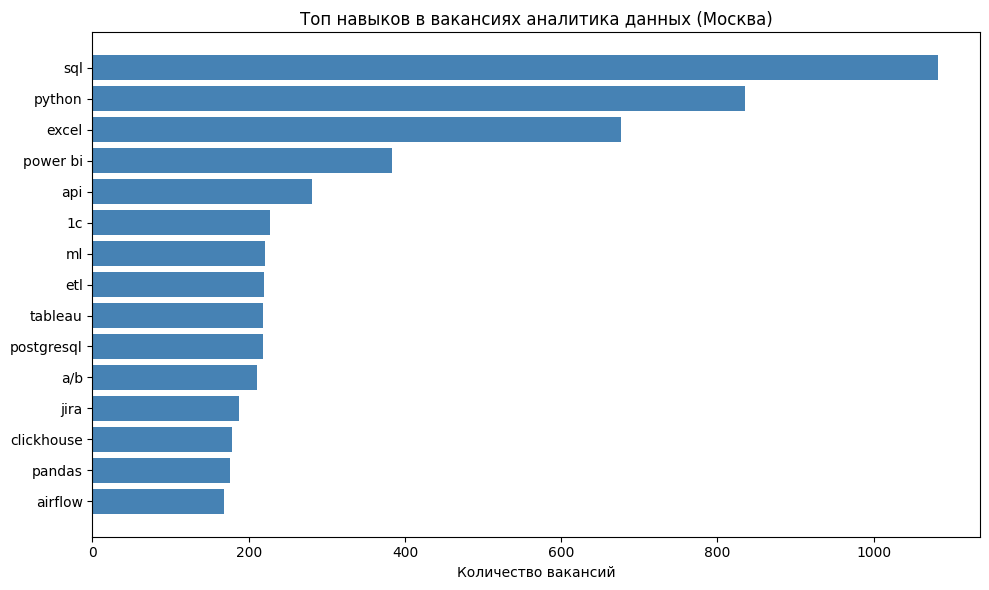

In [2]:
skills_df = pd.read_csv("data/skills_top.csv", encoding="utf-8-sig")
top15 = skills_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top15["skill"][::-1], top15["count"][::-1], color="steelblue")
plt.xlabel("Количество вакансий")
plt.title("Топ навыков в вакансиях аналитика данных (Москва)")
plt.tight_layout()
plt.show()

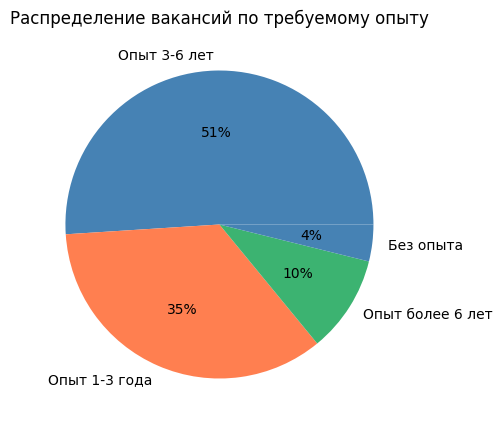

In [3]:
result = client.query("""
    SELECT experience, count() as cnt
    FROM hh.vacancies
    GROUP BY experience
    ORDER BY cnt DESC
""")
df_exp = pd.DataFrame(result.result_rows, columns=["experience", "count"])

plt.figure(figsize=(7, 5))
plt.pie(
    df_exp["count"],
    labels=df_exp["experience"],
    autopct="%1.0f%%",  # показываем проценты без десятичных
    colors=["steelblue", "coral", "mediumseagreen"]
)
plt.title("Распределение вакансий по требуемому опыту")
plt.show()

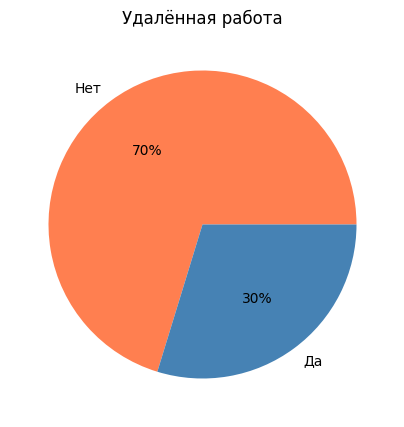

In [4]:
result = client.query("""
    SELECT remote, count() as cnt
    FROM hh.vacancies
    GROUP BY remote
""")
df_remote = pd.DataFrame(result.result_rows, columns=["remote", "count"])

plt.figure(figsize=(5, 5))
plt.pie(
    df_remote["count"],
    labels=df_remote["remote"],
    autopct="%1.0f%%",
    colors=["coral", "steelblue"]
)
plt.title("Удалённая работа")
plt.show()

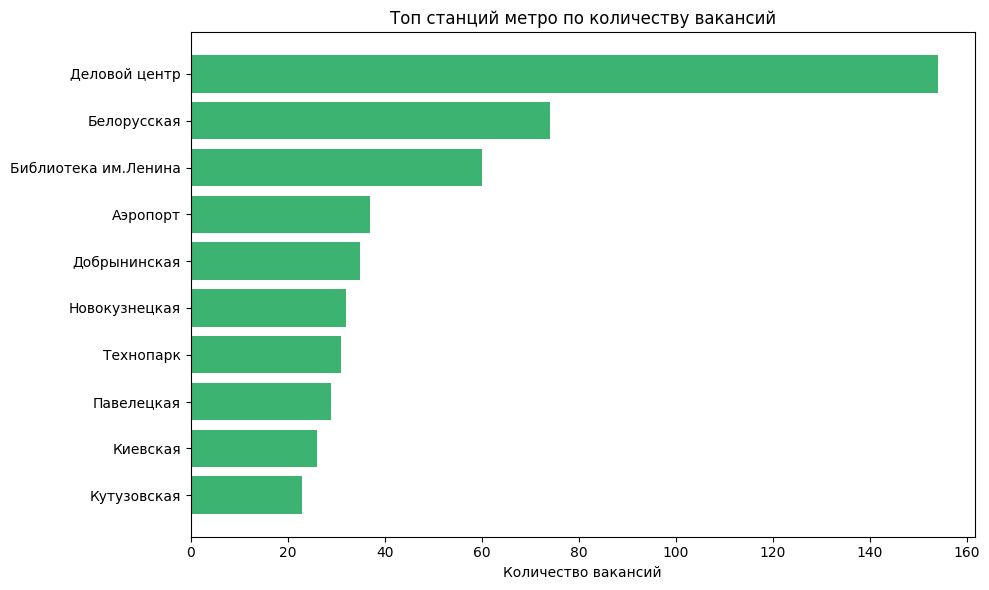

In [5]:
result = client.query("""
    SELECT metro, count() as cnt
    FROM hh.vacancies
    WHERE metro != 'Не указано'
      AND metro != ''
    GROUP BY metro
    ORDER BY cnt DESC
    LIMIT 10
""")
df_metro = pd.DataFrame(result.result_rows, columns=["metro", "count"])

plt.figure(figsize=(10, 6))
plt.barh(df_metro["metro"][::-1], df_metro["count"][::-1], color="mediumseagreen")
plt.xlabel("Количество вакансий")
plt.title("Топ станций метро по количеству вакансий")
plt.tight_layout()
plt.show()

In [8]:
result = client.query("""
    SELECT 
        experience,
        arrayJoin(splitByString(', ', skills_found)) as skill,
        count() as cnt
    FROM hh.vacancies
    WHERE skills_found != 'Не найдено'
      AND skills_found != 'Не указаны'
    GROUP BY experience, skill
    ORDER BY experience, cnt DESC
""")

df_skills_exp = pd.DataFrame(result.result_rows, columns=["experience", "skill", "count"])

# Берём топ-8 навыков для каждого уровня опыта
top_per_exp = df_skills_exp.groupby("experience", group_keys=False).apply(
    lambda x: x.nlargest(8, "count")
).reset_index(drop=True)

# Строим график для каждого уровня опыта
experiences = top_per_exp["experience"].unique()
fig, axes = plt.subplots(1, len(experiences), figsize=(18, 6))

for ax, exp in zip(axes, experiences):
    data = top_per_exp[top_per_exp["experience"] == exp]
    ax.barh(data["skill"][::-1], data["count"][::-1], color="steelblue")
    ax.set_title(exp)
    ax.set_xlabel("Количество вакансий")

plt.suptitle("Топ навыков по уровню опыта", fontsize=14)
plt.tight_layout()
plt.show()

KeyError: 'experience'